<a href="https://colab.research.google.com/github/luczux1/Expense_tracker/blob/main/NLP_powered_Online_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# IMDB Sentiment Classification Project
# Model: TF-IDF + Logistic Regression
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# =========================================================
# 1. Load IMDB dataset
# =========================================================

num_words = 20000

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = imdb.load_data(num_words=num_words)

print("Training samples:", len(X_train_raw))
print("Test samples:", len(X_test_raw))
print("Example label:", y_train_raw[0])
print("Example sequence:", X_train_raw[0][:20])

Training samples: 25000
Test samples: 25000
Example label: 1
Example sequence: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


In [ ]:
# =========================================================
# 2. Decode integer sequences back to text
# =========================================================

word_index = imdb.get_word_index()

# Keras reserves index 0, 1, 2, 3 for special tokens
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join([reverse_word_index.get(i, "<UNK>") for i in sequence])

X_train_text = [decode_review(seq) for seq in X_train_raw]
X_test_text = [decode_review(seq) for seq in X_test_raw]

y_train = np.array(y_train_raw)
y_test = np.array(y_test_raw)

print("Decoded review example:")
print(X_train_text[0][:500])
print("Label:", y_train[0])

Decoded review example:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would r
Label: 1


In [ ]:
# =========================================================
# 3. Create validation set
# Train: 70%, Validation: 15%, Test: 15% approximately
# Keras already gives 25,000 train and 25,000 test.
# Here we split original training data into train + validation.
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

X_test = X_test_text

print("Final training size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Final training size: 20000
Validation size: 5000
Test size: 25000


In [ ]:
# =========================================================
# 4. Convert text into numerical features using TF-IDF
# =========================================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    lowercase=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Validation feature shape:", X_val_tfidf.shape)
print("Test feature shape:", X_test_tfidf.shape)

Training feature shape: (20000, 10000)
Validation feature shape: (5000, 10000)
Test feature shape: (25000, 10000)


In [ ]:
# =========================================================
# 5. Train Logistic Regression model
# =========================================================

model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
# =========================================================
# 6. Evaluate on validation set
# =========================================================

y_val_pred = model.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)
print("\nValidation Classification Report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["negative", "positive"]
))

Validation Accuracy: 0.8822

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      2500
    positive       0.87      0.89      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [ ]:
# =========================================================
# 7. Evaluate on test set
# =========================================================

y_test_pred = model.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)
print("\nTest Classification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["negative", "positive"]
))

Test Accuracy: 0.87772

Test Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.87      0.88     12500
    positive       0.87      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



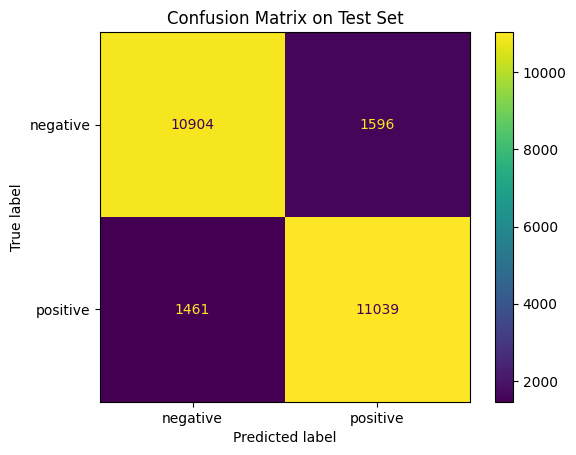

In [ ]:
# =========================================================
# 8. Confusion Matrix
# =========================================================

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Confusion Matrix on Test Set")
plt.show()

In [ ]:
# =========================================================
# 9. Test custom reviews
# =========================================================

custom_reviews = [
    "This movie was amazing. The story was exciting and the acting was excellent.",
    "The film was boring, too long, and the plot made no sense.",
    "I really enjoyed this movie and would recommend it to my friends.",
    "This was one of the worst movies I have ever watched."
]

custom_tfidf = vectorizer.transform(custom_reviews)
custom_predictions = model.predict(custom_tfidf)

for review, prediction in zip(custom_reviews, custom_predictions):
    sentiment = "positive" if prediction == 1 else "negative"
    print("Review:", review)
    print("Predicted sentiment:", sentiment)
    print("-" * 80)

Review: This movie was amazing. The story was exciting and the acting was excellent.
Predicted sentiment: positive
--------------------------------------------------------------------------------
Review: The film was boring, too long, and the plot made no sense.
Predicted sentiment: negative
--------------------------------------------------------------------------------
Review: I really enjoyed this movie and would recommend it to my friends.
Predicted sentiment: positive
--------------------------------------------------------------------------------
Review: This was one of the worst movies I have ever watched.
Predicted sentiment: negative
--------------------------------------------------------------------------------


In [ ]:
# =========================================================
# 10. Generalization Gap Analysis
# =========================================================

y_train_pred = model.predict(X_train_tfidf)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

print("Train-Val Gap:", train_accuracy - val_accuracy)
print("Val-Test Gap:", val_accuracy - test_accuracy)

Training Accuracy: 0.92735
Validation Accuracy: 0.8822
Test Accuracy: 0.87772
Train-Val Gap: 0.04515000000000002
Val-Test Gap: 0.0044800000000000395


In [ ]:
# =========================================================
# 11. High-confidence Error Analysis (Custom Metric)
# =========================================================

test_probs = model.predict_proba(X_test_tfidf)

# 每个样本的最大概率（模型自信程度）
confidence = np.max(test_probs, axis=1)

wrong_mask = (y_test_pred != y_test)

# 高置信度但预测错误（>= 0.9）
high_conf_wrong_mask = wrong_mask & (confidence >= 0.9)

high_conf_error_rate = high_conf_wrong_mask.sum() / len(y_test)

print("Total samples:", len(y_test))
print("Wrong predictions:", wrong_mask.sum())
print("High-confidence wrong:", high_conf_wrong_mask.sum())
print("High-confidence error rate:", high_conf_error_rate)

Total samples: 25000
Wrong predictions: 3057
High-confidence wrong: 58
High-confidence error rate: 0.00232


In [ ]:
# =========================================================
# 12. Error Case Analysis
# =========================================================

wrong_indices = np.where(wrong_mask)[0]

print("\nSample misclassified reviews:\n")

for i in wrong_indices[:5]:
    print("True label:", "positive" if y_test[i] == 1 else "negative")
    print("Predicted:", "positive" if y_test_pred[i] == 1 else "negative")
    print("Confidence:", confidence[i])
    print("Review:", X_test[i][:500])
    print("-" * 80)


Sample misclassified reviews:

True label: negative
Predicted: positive
Confidence: 0.8866547578031988
Review: <START> hollywood had a long love affair with bogus arabian nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs anachronistic slang and slapstick it's a truly crop of corn and pretty near intolerable today it was nominated for its imaginative special effects which are almost <UNK> in this day and age consisting mainly of trick photography the only outstandi
--------------------------------------------------------------------------------
True label: negative
Predicted: positive
Confidence: 0.6219798299450674
Review: <START> ed <UNK> mitchell is a teenager who lives for his job at good burger a small but friendly neighborhood <UNK> stand while his buddy dexter thompson also works there but lack <UNK> single minded devotion to his job he's 

In [ ]:
# =========================================================
# 13. Show important words learned by the model
# =========================================================

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_positive_indices = np.argsort(coefficients)[-20:]
top_negative_indices = np.argsort(coefficients)[:20]

print("Top positive words:")
print(feature_names[top_positive_indices])

print("\nTop negative words:")
print(feature_names[top_negative_indices])

Top positive words:
['fantastic' 'bit' 'job' 'definitely' 'highly' 'today' 'beautiful'
 'superb' 'enjoyed' 'brilliant' 'fun' 'loved' 'amazing' 'favorite' 'love'
 'perfect' 'wonderful' 'best' 'excellent' 'great']

Top negative words:
['worst' 'bad' 'waste' 'awful' 'boring' 'poor' 'worse' 'terrible' 'poorly'
 'dull' 'disappointment' 'horrible' 'unfortunately' 'minutes' 'ridiculous'
 'script' 'disappointing' 'fails' 'annoying' 'supposed']


In [ ]:
# =========================================================
# 14. Simple result summary for report
# =========================================================

summary = pd.DataFrame({
    "Dataset": ["Validation Set", "Test Set"],
    "Accuracy": [val_accuracy, test_accuracy]
})

summary

,Dataset,Accuracy
0,Validation Set,0.88220
1,Test Set,0.87772


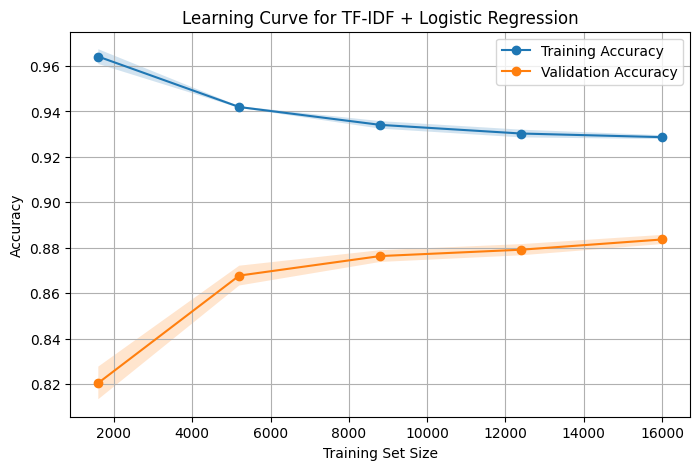

In [ ]:
# =========================================================
# 13. Learning Curve Analysis
# =========================================================

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_tfidf,
    y=y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy")

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for TF-IDF + Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()